# Analisis Komparatif Algoritma XGBoost dan CatBoost
## untuk Sistem Deteksi Intrusi pada Dataset NF-UNSW-NB15-v3

Notebook ini menyajikan eksperimen komparatif yang **fair, reproducible, dan siap ditransformasikan ke naskah jurnal** untuk membandingkan dua model gradient boosting pada tugas **Intrusion Detection System (IDS)**.

### Alur notebook
1. **Setup eksperimen** dan verifikasi environment/library.
2. **Pemanggilan dataset** serta audit singkat kualitas data awal.
3. **Split data yang fair** dan preprocessing dengan dukungan fitur kategorikal native.
4. **Pelatihan, evaluasi kuantitatif, dan cross-validation** pada dua baseline model.
5. **Visualisasi siap publikasi**: distribusi label, komparasi metrik, confusion matrix, efisiensi komputasi, dan heatmap.
6. **Ringkasan analitis, checklist naskah, dan kesimpulan otomatis** untuk membantu penulisan artikel.

> Output utama notebook: tabel komparasi model, distribusi label, validasi stratified split, confusion matrix raw/normalized, komparasi waktu komputasi, heatmap metrik, serta narasi analitis yang mudah diadaptasi ke laporan atau jurnal.

## 1) Tujuan Komparasi dan Kontribusi Analisis

Notebook ini difokuskan untuk membandingkan performa **XGBoost** dan **CatBoost** pada dataset **NF-UNSW-NB15-v3** dengan alur evaluasi yang konsisten, sehingga hasilnya mudah dibaca oleh reviewer maupun penulis artikel.

### Tujuan utama
- Membandingkan performa dua model pada tugas klasifikasi multiclass untuk IDS.
- Mengidentifikasi model terbaik berdasarkan kombinasi **akurasi**, **stabilitas antar-kelas**, dan **efisiensi komputasi**.
- Menyediakan keluaran yang siap digunakan pada naskah jurnal: tabel komparasi, visualisasi, dan interpretasi otomatis.

### Metrik utama yang digunakan
- Accuracy
- Balanced Accuracy
- Precision (weighted)
- Recall (weighted)
- F1-Score (weighted)
- Matthews Correlation Coefficient (MCC)
- ROC-AUC (OvR, weighted)
- Waktu latih (training time)
- Waktu inferensi per sampel

### Prinsip fairness eksperimen
- Semua model menggunakan **split train/test yang sama**.
- Semua model menggunakan **preprocessing yang sama**.
- Penanganan imbalance dilakukan dengan **class weighting** berbasis data train.
- Evaluasi menggabungkan **hold-out test** dan **cross-validation weighted F1**.

In [1]:
# 2) Setup Eksperimen (Seed, Environment, Versi Library, Gaya Visual)
import os
import time
import random
import warnings
import platform
from pathlib import Path
from textwrap import fill

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.base import clone
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    roc_auc_score,
    confusion_matrix,
    classification_report,
)

from xgboost import XGBClassifier
from catboost import CatBoostClassifier

try:
    from IPython.display import display, Markdown
except Exception:
    def display(x):
        print(x)

    class Markdown(str):
        pass

warnings.filterwarnings("ignore")

SEED = 42
TEST_SIZE = 0.2
RANDOM_STATE = SEED

random.seed(SEED)
np.random.seed(SEED)

# Pengaturan visual global agar konsisten untuk kebutuhan laporan/jurnal
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.dpi": 130,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "axes.titlesize": 13,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "legend.frameon": True,
    "legend.title_fontsize": 10,
    "font.size": 10,
})
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

IS_KAGGLE = Path("/kaggle/input").exists()
RUN_ENV = "Kaggle Notebook" if IS_KAGGLE else "Local/Other"


def wrap_labels(labels, width=18):
    return [fill(str(label), width=width) for label in labels]


def annotate_bars(ax, fmt="{:.3f}", orient="v", fontsize=9, pad=3):
    for patch in ax.patches:
        value = patch.get_width() if orient == "h" else patch.get_height()
        if not np.isfinite(value):
            continue

        if orient == "h":
            x = value
            y = patch.get_y() + patch.get_height() / 2
            ax.annotate(
                fmt.format(value),
                (x, y),
                xytext=(4, 0),
                textcoords="offset points",
                ha="left",
                va="center",
                fontsize=fontsize,
            )
        else:
            x = patch.get_x() + patch.get_width() / 2
            y = value
            ax.annotate(
                fmt.format(value),
                (x, y),
                xytext=(0, pad),
                textcoords="offset points",
                ha="center",
                va="bottom",
                fontsize=fontsize,
            )


def style_metric_table(df, metric_cols=None, time_cols=None, caption=None):
    metric_cols = metric_cols or []
    time_cols = time_cols or []

    styler = df.style
    if caption:
        styler = styler.set_caption(caption)

    if metric_cols:
        styler = styler.background_gradient(cmap="YlGn", subset=metric_cols)

    if time_cols:
        styler = styler.background_gradient(cmap="YlOrRd_r", subset=time_cols)

    return styler.set_properties(**{"text-align": "center"}).set_table_styles(
        [
            {
                "selector": "caption",
                "props": [
                    ("caption-side", "top"),
                    ("font-weight", "bold"),
                    ("font-size", "1rem"),
                ],
            }
        ]
    )


def detect_xgboost_gpu():
    try:
        x_dummy = np.random.rand(128, 8)
        y_dummy = np.random.randint(0, 3, 128)
        model = XGBClassifier(
            n_estimators=1,
            max_depth=2,
            objective="multi:softprob",
            num_class=3,
            eval_metric="mlogloss",
            tree_method="hist",
            device="cuda",
            random_state=SEED,
        )
        model.fit(x_dummy, y_dummy)
        return True, ""
    except Exception as e:
        return False, str(e)


def detect_catboost_gpu():
    try:
        x_dummy = np.random.rand(128, 8)
        y_dummy = np.random.randint(0, 3, 128)
        model = CatBoostClassifier(
            iterations=1,
            depth=2,
            learning_rate=0.1,
            loss_function="MultiClass",
            task_type="GPU",
            devices="0",
            random_seed=SEED,
            verbose=False,
        )
        model.fit(x_dummy, y_dummy)
        return True, ""
    except Exception as e:
        return False, str(e)


XGB_GPU_ENABLED, xgb_gpu_err = detect_xgboost_gpu()
CAT_GPU_ENABLED, cat_gpu_err = detect_catboost_gpu()

GPU_PARAMS = {
    "XGBoost": {"tree_method": "hist", "device": "cuda"} if XGB_GPU_ENABLED else {"tree_method": "hist", "device": "cpu"},
    "CatBoost": {"task_type": "GPU", "devices": "0"} if CAT_GPU_ENABLED else {"task_type": "CPU"},
}

print("✅ Setup selesai")
print(f"Python      : {platform.python_version()}")
print(f"OS          : {platform.system()} {platform.release()}")
print(f"Environment : {RUN_ENV}")
print(f"Seed        : {SEED}")
print(f"XGBoost GPU : {'AKTIF' if XGB_GPU_ENABLED else 'CPU fallback'}")
if not XGB_GPU_ENABLED and xgb_gpu_err:
    print(f"  └─ Alasan fallback XGBoost: {xgb_gpu_err}")
print(f"CatBoost GPU: {'AKTIF' if CAT_GPU_ENABLED else 'CPU fallback'}")
if not CAT_GPU_ENABLED and cat_gpu_err:
    print(f"  └─ Alasan fallback CatBoost: {cat_gpu_err}")

✅ Setup selesai
Python      : 3.12.12
OS          : Linux 6.6.113+
Environment : Kaggle Notebook
Seed        : 42
XGBoost GPU : AKTIF
CatBoost GPU: AKTIF


In [2]:
# Cek versi library agar eksperimen reproducible
import sklearn
import xgboost
import catboost

env_df = pd.DataFrame(
    [
        {"Komponen": "Python", "Nilai": platform.python_version()},
        {"Komponen": "Sistem Operasi", "Nilai": f"{platform.system()} {platform.release()}"},
        {"Komponen": "Environment", "Nilai": RUN_ENV},
        {"Komponen": "Seed", "Nilai": SEED},
        {"Komponen": "XGBoost GPU", "Nilai": "AKTIF" if XGB_GPU_ENABLED else "CPU fallback"},
        {"Komponen": "CatBoost GPU", "Nilai": "AKTIF" if CAT_GPU_ENABLED else "CPU fallback"},
    ]
)

version_df = pd.DataFrame(
    [
        {"Library": "pandas", "Versi": pd.__version__},
        {"Library": "numpy", "Versi": np.__version__},
        {"Library": "scikit-learn", "Versi": sklearn.__version__},
        {"Library": "xgboost", "Versi": xgboost.__version__},
        {"Library": "catboost", "Versi": catboost.__version__},
    ]
)

display(style_metric_table(env_df, caption="Ringkasan environment eksperimen"))
display(style_metric_table(version_df, caption="Versi library utama"))

,Komponen,Nilai
0,Python,3.12.12
1,Sistem Operasi,Linux 6.6.113+
2,Environment,Kaggle Notebook
3,Seed,42
4,XGBoost GPU,AKTIF
5,CatBoost GPU,AKTIF


,Library,Versi
0,pandas,2.3.3
1,numpy,2.0.2
2,scikit-learn,1.6.1
3,xgboost,3.2.0
4,catboost,1.2.10


## 3) Pemanggilan Dataset dan Audit Singkat

Bagian ini mencari file dataset secara otomatis dari beberapa lokasi umum (Kaggle maupun lokal), lalu menampilkan **preview data**, **ringkasan struktur**, dan **distribusi label** untuk membantu audit awal dataset sebelum eksperimen dimulai.

In [3]:
# 3.1 Load dataset NF-UNSW-NB15-v3 (Kaggle-friendly)
candidate_paths = []

if IS_KAGGLE:
    print("🔍 Mencari dataset di /kaggle/input ...")
    for dirname, _, filenames in os.walk("/kaggle/input"):
        for filename in filenames:
            name = filename.lower()
            if name.endswith(".csv") and "nf-unsw-nb15-v3" in name and "features" not in name:
                candidate_paths.append(Path(dirname) / filename)

# Fallback lokal (tetap mendukung non-Kaggle)
candidate_paths.extend([
    Path("NF-UNSW-NB15-v3.csv"),
    Path("./data/NF-UNSW-NB15-v3.csv"),
    Path("./dataset/NF-UNSW-NB15-v3.csv"),
])

# Tambahan: cari file csv dengan nama yang mengandung NF-UNSW-NB15-v3
for p in Path(".").glob("**/*NF-UNSW-NB15-v3*.csv"):
    candidate_paths.append(p)

# Deduplicate sambil menjaga urutan
unique_candidates = []
seen = set()
for p in candidate_paths:
    p_str = str(p)
    if p_str not in seen:
        unique_candidates.append(p)
        seen.add(p_str)

dataset_path = next((p for p in unique_candidates if p.exists() and p.is_file()), None)

if dataset_path is None:
    raise FileNotFoundError(
        "Dataset NF-UNSW-NB15-v3 tidak ditemukan. Tambahkan dataset ke Kaggle Notebook (Input) "
        "atau letakkan file CSV di root project/folder data/dataset."
    )

df = pd.read_csv(dataset_path)
print(f"✅ Dataset ditemukan: {dataset_path}")
print(f"Shape data: {df.shape}")

display(
    df.head(3).style.set_caption("Cuplikan 3 baris pertama dataset")
)

🔍 Mencari dataset di /kaggle/input ...
✅ Dataset ditemukan: /kaggle/input/datasets/rachmanantaibnufajar/nf-unsw-nb15-v3/NF-UNSW-NB15-v3.csv
Shape data: (2365424, 55)


,FLOW_START_MILLISECONDS,FLOW_END_MILLISECONDS,IPV4_SRC_ADDR,L4_SRC_PORT,IPV4_DST_ADDR,L4_DST_PORT,PROTOCOL,L7_PROTO,IN_BYTES,IN_PKTS,OUT_BYTES,OUT_PKTS,TCP_FLAGS,CLIENT_TCP_FLAGS,SERVER_TCP_FLAGS,FLOW_DURATION_MILLISECONDS,DURATION_IN,DURATION_OUT,MIN_TTL,MAX_TTL,LONGEST_FLOW_PKT,SHORTEST_FLOW_PKT,MIN_IP_PKT_LEN,MAX_IP_PKT_LEN,SRC_TO_DST_SECOND_BYTES,DST_TO_SRC_SECOND_BYTES,RETRANSMITTED_IN_BYTES,RETRANSMITTED_IN_PKTS,RETRANSMITTED_OUT_BYTES,RETRANSMITTED_OUT_PKTS,SRC_TO_DST_AVG_THROUGHPUT,DST_TO_SRC_AVG_THROUGHPUT,NUM_PKTS_UP_TO_128_BYTES,NUM_PKTS_128_TO_256_BYTES,NUM_PKTS_256_TO_512_BYTES,NUM_PKTS_512_TO_1024_BYTES,NUM_PKTS_1024_TO_1514_BYTES,TCP_WIN_MAX_IN,TCP_WIN_MAX_OUT,ICMP_TYPE,ICMP_IPV4_TYPE,DNS_QUERY_ID,DNS_QUERY_TYPE,DNS_TTL_ANSWER,FTP_COMMAND_RET_CODE,SRC_TO_DST_IAT_MIN,SRC_TO_DST_IAT_MAX,SRC_TO_DST_IAT_AVG,SRC_TO_DST_IAT_STDDEV,DST_TO_SRC_IAT_MIN,DST_TO_SRC_IAT_MAX,DST_TO_SRC_IAT_AVG,DST_TO_SRC_IAT_STDDEV,Label,Attack
0,1424242193040,1424242193043,59.166.0.2,4894,149.171.126.3,53,17,5.000000,146,2,178,2,0,0,0,2,0,0,31,31,89,73,73,89,89.000000,73.000000,0,0,0,0,389333,474666,4,0,0,0,0,0,0,0,0,46779,1,60,0,0,0,0,0,0,0,0,0,0,Benign
1,1424242192744,1424242193079,59.166.0.4,52671,149.171.126.6,31992,6,11.000000,4704,28,2976,28,27,27,27,335,334,334,31,32,984,52,52,984,8.883582,14.041791,1988,7,1068,6,112000,70857,34,18,2,2,0,14480,14480,50176,196,0,0,0,0,0,91,12,19,0,90,12,19,0,Benign
2,1424242190649,1424242193109,59.166.0.0,47290,149.171.126.9,6881,6,37.000000,13662,238,548216,438,27,27,27,2460,2459,2459,31,32,1500,52,52,1500,222.852033,5.553659,1735,21,272908,196,44411,1782091,288,0,4,32,352,65160,34752,50944,199,0,0,0,0,0,1843,10,119,0,1843,5,88,0,Benign


✅ Kolom label yang digunakan: Attack


,Metrik,Nilai
0,Jumlah baris,2365424
1,Jumlah kolom,55
2,Duplikat awal,14815
3,Nilai hilang total,63425
4,Jumlah kelas,10


,Tipe data,Jumlah kolom
0,int64,49
1,object,3
2,float64,3


,Kelas,Jumlah,Proporsi (%)
0,Benign,"2,237,731",94.60
1,Exploits,"42,748",1.81
2,Fuzzers,"33,816",1.43
3,Generic,"19,651",0.83
4,Reconnaissance,"17,074",0.72
5,DoS,"5,980",0.25
6,Backdoor,"4,659",0.20
7,Shellcode,"2,381",0.10
8,Analysis,"1,226",0.05
9,Worms,158,0.01


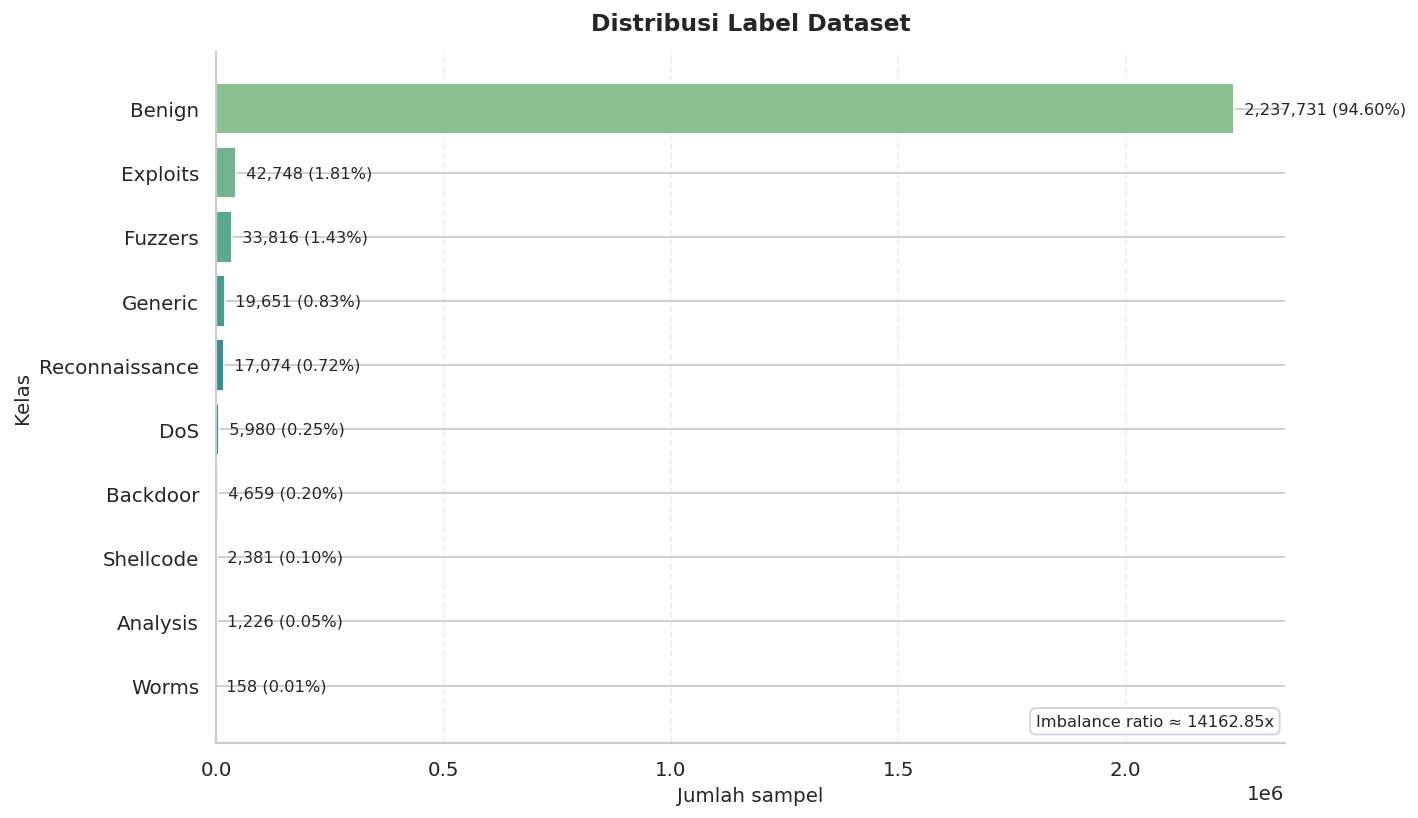

In [4]:
# 3.2 Audit singkat struktur data + distribusi label
# Deteksi kolom label secara fleksibel
label_candidates = ["Attack"]
label_col = next((c for c in label_candidates if c in df.columns), None)

if label_col is None:
    raise ValueError(f"Kolom label tidak ditemukan. Kandidat yang dicek: {label_candidates}")

print(f"✅ Kolom label yang digunakan: {label_col}")

label_counts = df[label_col].astype(str).value_counts(dropna=False).sort_values(ascending=False)
label_dist_df = pd.DataFrame({
    "Kelas": label_counts.index,
    "Jumlah": label_counts.values,
    "Proporsi (%)": (label_counts.values / label_counts.sum()) * 100,
})

overview_df = pd.DataFrame(
    [
        {"Metrik": "Jumlah baris", "Nilai": len(df)},
        {"Metrik": "Jumlah kolom", "Nilai": df.shape[1]},
        {"Metrik": "Duplikat awal", "Nilai": int(df.duplicated().sum())},
        {"Metrik": "Nilai hilang total", "Nilai": int(df.isna().sum().sum())},
        {"Metrik": "Jumlah kelas", "Nilai": label_counts.shape[0]},
    ]
)

dtype_df = (
    df.dtypes.astype(str)
    .value_counts()
    .rename_axis("Tipe data")
    .reset_index(name="Jumlah kolom")
)

display(style_metric_table(overview_df, caption="Ringkasan awal dataset"))
display(style_metric_table(dtype_df, caption="Komposisi tipe data"))

display(
    label_dist_df.style
    .format({"Jumlah": "{:,.0f}", "Proporsi (%)": "{:.2f}"})
    .background_gradient(cmap="Blues", subset=["Jumlah", "Proporsi (%)"])
    .set_caption("Distribusi label")
)

fig_h = max(4.8, 0.48 * len(label_dist_df) + 1.6)
fig, ax = plt.subplots(figsize=(11, fig_h))
wrapped_class_labels = wrap_labels(label_dist_df["Kelas"], width=22)
bars = ax.barh(
    wrapped_class_labels,
    label_dist_df["Jumlah"],
    color=sns.color_palette("crest", n_colors=len(label_dist_df)),
)

for bar, count, pct in zip(bars, label_dist_df["Jumlah"], label_dist_df["Proporsi (%)"]):
    ax.text(
        bar.get_width(),
        bar.get_y() + bar.get_height() / 2,
        f"  {count:,.0f} ({pct:.2f}%)",
        va="center",
        ha="left",
        fontsize=9,
    )

label_ratio = label_counts.max() / label_counts.min()
ax.set_title("Distribusi Label Dataset", pad=12)
ax.set_xlabel("Jumlah sampel")
ax.set_ylabel("Kelas")
ax.grid(axis="x", linestyle="--", alpha=0.3)
ax.invert_yaxis()
ax.text(
    0.99,
    0.02,
    f"Imbalance ratio ≈ {label_ratio:.2f}x",
    transform=ax.transAxes,
    ha="right",
    va="bottom",
    fontsize=9,
    bbox={"boxstyle": "round,pad=0.35", "facecolor": "white", "edgecolor": "#cbd5e1"},
)

plt.tight_layout()
plt.show()

## 4) Definisi Skenario Eksperimen dan Split Data

- Skenario dipaksa ke **multiclass**, sesuai tujuan komparasi jurnal.
- Seluruh model menggunakan **split train/test yang sama** untuk menjaga fairness.
- Validasi stratifikasi ditampilkan agar distribusi train dan test tetap seimbang secara proporsional.

> Tujuan bagian ini adalah memastikan eksperimen adil sejak tahap persiapan data.

Skenario eksperimen: multiclass (10 kelas)


,Komponen,Nilai
0,Jumlah sampel setelah drop duplicates,2350609
1,Jumlah fitur untuk model,54
2,Jumlah kelas,10
3,Proporsi data train,80%
4,Proporsi data test,20%
5,Ukuran train,"1,880,487 x 54"
6,Ukuran test,"470,122 x 54"


,Kelas,Train (%),Test (%)
0,Analysis,0.05,0.05
1,Backdoor,0.20,0.20
2,Benign,94.57,94.57
3,DoS,0.25,0.25
4,Exploits,1.82,1.82
5,Fuzzers,1.44,1.44
6,Generic,0.84,0.84
7,Reconnaissance,0.73,0.73
8,Shellcode,0.10,0.10
9,Worms,0.01,0.01


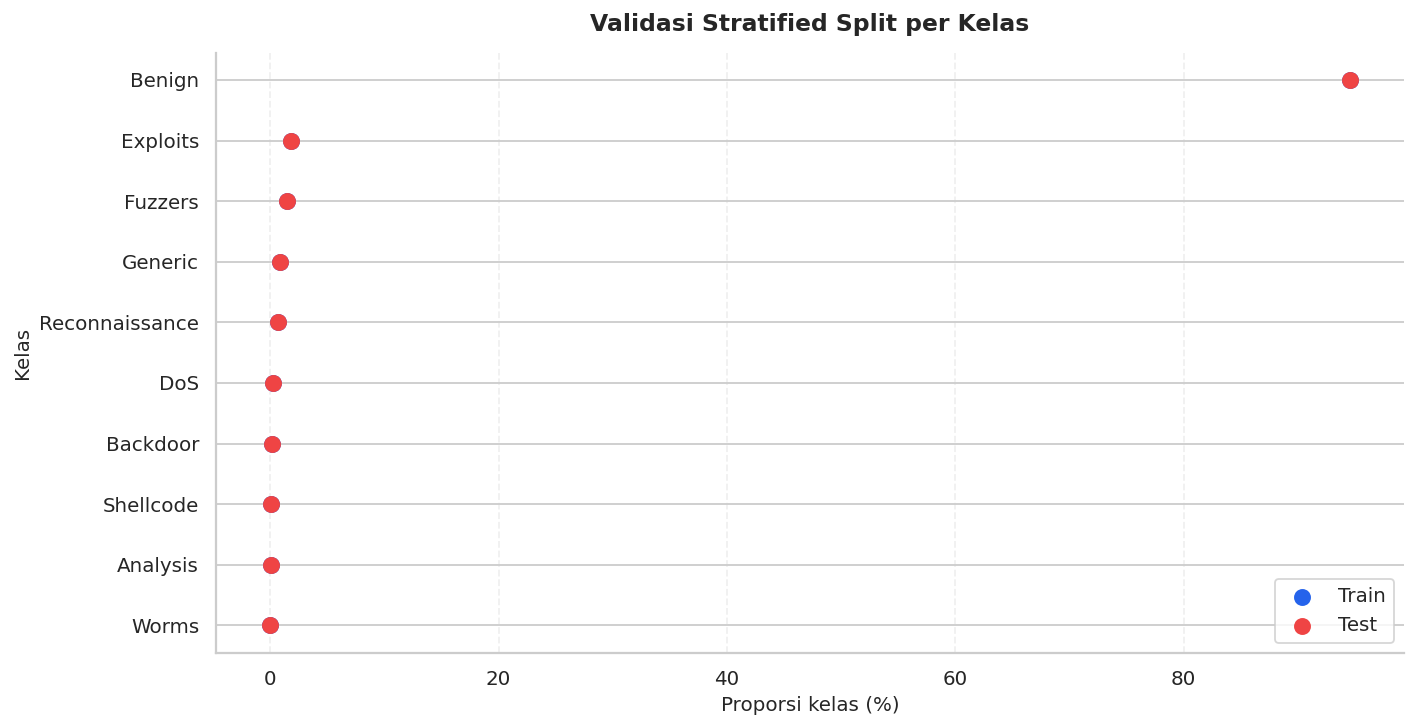

In [5]:
# 4.1 Pembersihan data minimum + split
# Hapus duplikasi baris (minimum cleaning)
df = df.drop_duplicates().reset_index(drop=True)

X = df.drop(columns=[label_col]).copy()
y_raw = df[label_col].copy()

# Drop kolom ID bila ada (umum pada dataset network flow)
id_like_cols = [c for c in X.columns if c.lower() in {"id", "flow_id", "index"}]
if id_like_cols:
    X = X.drop(columns=id_like_cols)
    print(f"Kolom ID dihapus: {id_like_cols}")

# Encoding label
y_encoder = LabelEncoder()
y = y_encoder.fit_transform(y_raw.astype(str))
class_names = list(y_encoder.classes_)

n_classes = len(np.unique(y))
if n_classes < 3:
    raise ValueError(f"Notebook ini difokuskan untuk multiclass, tetapi hanya terdeteksi {n_classes} kelas.")

scenario = "multiclass"
print(f"Skenario eksperimen: {scenario} ({n_classes} kelas)")

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

split_summary_df = pd.DataFrame(
    [
        {"Komponen": "Jumlah sampel setelah drop duplicates", "Nilai": len(df)},
        {"Komponen": "Jumlah fitur untuk model", "Nilai": X.shape[1]},
        {"Komponen": "Jumlah kelas", "Nilai": n_classes},
        {"Komponen": "Proporsi data train", "Nilai": f"{1 - TEST_SIZE:.0%}"},
        {"Komponen": "Proporsi data test", "Nilai": f"{TEST_SIZE:.0%}"},
        {"Komponen": "Ukuran train", "Nilai": f"{X_train.shape[0]:,} x {X_train.shape[1]:,}"},
        {"Komponen": "Ukuran test", "Nilai": f"{X_test.shape[0]:,} x {X_test.shape[1]:,}"},
    ]
)

display(style_metric_table(split_summary_df, caption="Ringkasan skenario dan split data"))

train_prop = pd.Series(y_train).value_counts(normalize=True).sort_index()
test_prop = pd.Series(y_test).value_counts(normalize=True).sort_index()

split_dist_df = pd.DataFrame({
    "Kelas": [str(c) for c in class_names],
    "Train (%)": train_prop.reindex(range(n_classes), fill_value=0).values * 100,
    "Test (%)": test_prop.reindex(range(n_classes), fill_value=0).values * 100,
})

display(
    split_dist_df.style
    .format({"Train (%)": "{:.2f}", "Test (%)": "{:.2f}"})
    .set_caption("Validasi proporsi kelas pada train/test (stratified split)")
)

plot_df = split_dist_df.sort_values("Train (%)", ascending=True).reset_index(drop=True)
y_pos = np.arange(len(plot_df))

fig_h = max(4.5, 0.45 * len(plot_df) + 1.2)
fig, ax = plt.subplots(figsize=(11, fig_h))
ax.hlines(y=y_pos, xmin=plot_df["Train (%)"], xmax=plot_df["Test (%)"], color="#cbd5e1", linewidth=2)
ax.scatter(plot_df["Train (%)"], y_pos, s=70, label="Train", color="#2563eb")
ax.scatter(plot_df["Test (%)"], y_pos, s=70, label="Test", color="#ef4444")
ax.set_yticks(y_pos)
ax.set_yticklabels(wrap_labels(plot_df["Kelas"], width=22))
ax.set_xlabel("Proporsi kelas (%)")
ax.set_ylabel("Kelas")
ax.set_title("Validasi Stratified Split per Kelas", pad=12)
ax.grid(axis="x", linestyle="--", alpha=0.3)
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

## 5) Preprocessing Fitur Kategorikal Native untuk Semua Model

Preprocessing dirancang agar **identik untuk seluruh model** namun tetap mempertahankan keuntungan native categorical handling.

### Langkah utama
- Imputasi missing value numerik dengan **median dari data train**.
- Imputasi missing value kategorikal dengan token **`MISSING`**.
- Kategori baru pada data uji dipetakan ke **`UNKNOWN`**.
- Kolom kategorikal dipertahankan pada dtype **`category`** agar bisa dimanfaatkan secara native.

> Catatan fairness: tidak digunakan one-hot encoding, sehingga kedua model berangkat dari skenario input yang setara.

In [6]:
# 5.1 Preprocessing tanpa one-hot (native categorical) + class weighting multiclass
categorical_cols = X_train.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
numeric_cols = [c for c in X_train.columns if c not in categorical_cols]

X_train_prep = X_train.copy()
X_test_prep = X_test.copy()

X_train_prep[numeric_cols] = X_train_prep[numeric_cols].replace([np.inf, -np.inf], np.nan)
X_test_prep[numeric_cols] = X_test_prep[numeric_cols].replace([np.inf, -np.inf], np.nan)

# Imputasi numerik berbasis train
if numeric_cols:
    num_imputer = SimpleImputer(strategy="median")
    X_train_prep[numeric_cols] = num_imputer.fit_transform(X_train_prep[numeric_cols])
    X_test_prep[numeric_cols] = num_imputer.transform(X_test_prep[numeric_cols])

# Imputasi + casting kategorikal ke dtype category agar native categorical tetap aktif
for col in categorical_cols:
    train_col = X_train_prep[col].astype("string").fillna("MISSING")
    test_col = X_test_prep[col].astype("string").fillna("MISSING")

    train_categories = pd.Index(train_col.unique())
    if "UNKNOWN" not in train_categories:
        train_categories = train_categories.append(pd.Index(["UNKNOWN"]))

    unseen_mask = ~test_col.isin(train_categories)
    test_col = test_col.mask(unseen_mask, "UNKNOWN")

    X_train_prep[col] = pd.Categorical(train_col, categories=train_categories)
    X_test_prep[col] = pd.Categorical(test_col, categories=train_categories)

classes = np.unique(y_train)
class_weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_train)
class_weight_map = {int(cls): float(w) for cls, w in zip(classes, class_weights)}
sample_weight_train = np.array([class_weight_map[y] for y in y_train], dtype=float)

prep_summary_df = pd.DataFrame(
    [
        {"Komponen": "Jumlah fitur awal", "Nilai": X_train.shape[1]},
        {"Komponen": "Jumlah fitur kategorikal", "Nilai": len(categorical_cols)},
        {"Komponen": "Jumlah fitur numerik", "Nilai": len(numeric_cols)},
        {"Komponen": "Strategi imputasi numerik", "Nilai": "Median"},
        {"Komponen": "Strategi imputasi kategorikal", "Nilai": "MISSING / UNKNOWN"},
    ]
)

class_weight_preview_df = pd.DataFrame(
    [
        {"Encoded Class": cls, "Class Weight": weight}
        for cls, weight in class_weight_map.items()
    ]
)

display(style_metric_table(prep_summary_df, caption="Ringkasan preprocessing"))
display(
    style_metric_table(
        class_weight_preview_df,
        metric_cols=["Class Weight"],
        caption="Preview class weight untuk penanganan imbalance"
    ).format({"Class Weight": "{:.4f}"})
)

print("✅ Preprocessing selesai (native categorical)")

,Komponen,Nilai
0,Jumlah fitur awal,54
1,Jumlah fitur kategorikal,2
2,Jumlah fitur numerik,52
3,Strategi imputasi numerik,Median
4,Strategi imputasi kategorikal,MISSING / UNKNOWN


,Encoded Class,Class Weight
0,0,191.6908
1,1,50.4693
2,2,0.1057
3,3,39.3654
4,4,5.4993
5,5,6.9511
6,6,11.9616
7,7,13.7674
8,8,98.7132
9,9,1492.4500


✅ Preprocessing selesai (native categorical)


## 6) Definisi Baseline Dua Model

Bagian ini menyiapkan dua baseline model yang akan dibandingkan secara langsung:

- **XGBoost** dengan dukungan `enable_categorical=True`
- **CatBoost** dengan penentuan `cat_features` saat proses fit

Konfigurasi di bawah sengaja dibuat sebagai **baseline yang wajar** untuk komparasi awal, sebelum tahap tuning hiperparameter lanjutan.

In [7]:
# 6.1 Baseline model multiclass
xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.1,
    max_depth=6,
    subsample=0.9,
    colsample_bytree=0.9,
    objective="multi:softprob",
    num_class=n_classes,
    eval_metric="mlogloss",
    random_state=SEED,
    n_jobs=-1,
    enable_categorical=True,
    **GPU_PARAMS["XGBoost"],
)

cat_model = CatBoostClassifier(
    iterations=300,
    learning_rate=0.1,
    depth=6,
    loss_function="MultiClass",
    random_seed=SEED,
    verbose=0,
    **GPU_PARAMS["CatBoost"],
)

models = {
    "XGBoost": xgb_model,
    "CatBoost": cat_model,
}

model_config_df = pd.DataFrame(
    [
        {
            "Model": "XGBoost",
            "Estimator": "XGBClassifier",
            "n_estimators / iterations": 300,
            "learning_rate": 0.1,
            "depth / max_depth": 6,
            "Device": GPU_PARAMS["XGBoost"].get("device", "cpu"),
            "Cat. handling": "enable_categorical=True",
        },
        {
            "Model": "CatBoost",
            "Estimator": "CatBoostClassifier",
            "n_estimators / iterations": 300,
            "learning_rate": 0.1,
            "depth / max_depth": 6,
            "Device": GPU_PARAMS["CatBoost"].get("task_type", "CPU"),
            "Cat. handling": "cat_features saat fit",
        },
    ]
)

display(style_metric_table(model_config_df, caption="Konfigurasi baseline model"))
print("✅ Baseline model siap:", list(models.keys()))

,Model,Estimator,n_estimators / iterations,learning_rate,depth / max_depth,Device,Cat. handling
0,XGBoost,XGBClassifier,300,0.100000,6,cuda,enable_categorical=True
1,CatBoost,CatBoostClassifier,300,0.100000,6,GPU,cat_features saat fit


✅ Baseline model siap: ['XGBoost', 'CatBoost']


## 7) Pelatihan, Prediksi, dan Pencatatan Waktu

Setiap model dilatih pada data yang sama, menggunakan weighting yang sama, lalu dievaluasi pada hold-out test set. Selain metrik klasifikasi, notebook juga mencatat **waktu training** dan **waktu inferensi per sampel** untuk menilai kelayakan implementasi real-time.

In [8]:
# 7.1 Train + predict + timing
def normalize_pred_output(y_pred):
    """Normalisasi output prediksi agar konsisten 1D (lintas library)."""
    return np.asarray(y_pred).ravel()


results = []
trained_models = {}
predictions = {}
probabilities = {}

for name, model in models.items():
    print()
    print(f"🚀 Training {name}...")

    fit_kwargs = {"sample_weight": sample_weight_train}
    if name == "CatBoost":
        fit_kwargs["cat_features"] = categorical_cols

    try:
        t0 = time.perf_counter()
        model.fit(X_train_prep, y_train, **fit_kwargs)
        train_time = time.perf_counter() - t0

        t1 = time.perf_counter()
        y_pred = normalize_pred_output(model.predict(X_test_prep))
        infer_time_total = time.perf_counter() - t1
        infer_time_per_sample_ms = (infer_time_total / len(y_test)) * 1000

        if hasattr(model, "predict_proba"):
            y_proba = model.predict_proba(X_test_prep)
        else:
            y_proba = None

        acc = accuracy_score(y_test, y_pred)
        bal_acc = balanced_accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred, average="weighted", zero_division=0)
        rec = recall_score(y_test, y_pred, average="weighted", zero_division=0)
        f1 = f1_score(y_test, y_pred, average="weighted", zero_division=0)
        mcc = matthews_corrcoef(y_test, y_pred)

        if y_proba is None:
            roc_auc = np.nan
        else:
            try:
                roc_auc = roc_auc_score(y_test, y_proba, multi_class="ovr", average="weighted")
            except ValueError:
                roc_auc = np.nan

        results.append({
            "Model": name,
            "Accuracy": acc,
            "Balanced Accuracy": bal_acc,
            "Precision": prec,
            "Recall": rec,
            "F1": f1,
            "MCC": mcc,
            "ROC-AUC": roc_auc,
            "Train Time (s)": train_time,
            "Inference Total (s)": infer_time_total,
            "Inference / Sample (ms)": infer_time_per_sample_ms,
            "Error": np.nan,
        })

        trained_models[name] = model
        predictions[name] = y_pred
        probabilities[name] = y_proba

        print(
            f"✅ {name} selesai | F1={f1:.4f} | Recall={rec:.4f} | "
            f"Balanced Acc={bal_acc:.4f} | Train={train_time:.3f}s"
        )

    except Exception as e:
        results.append({
            "Model": name,
            "Accuracy": np.nan,
            "Balanced Accuracy": np.nan,
            "Precision": np.nan,
            "Recall": np.nan,
            "F1": np.nan,
            "MCC": np.nan,
            "ROC-AUC": np.nan,
            "Train Time (s)": np.nan,
            "Inference Total (s)": np.nan,
            "Inference / Sample (ms)": np.nan,
            "Error": str(e),
        })
        print(f"❌ {name} gagal dilatih: {e}")

if not trained_models:
    raise RuntimeError("Semua model gagal dilatih. Periksa dataset, versi library, dan konfigurasi GPU/CPU.")

train_summary_df = pd.DataFrame(results)
display(
    style_metric_table(
        train_summary_df,
        metric_cols=["Accuracy", "Balanced Accuracy", "Precision", "Recall", "F1", "MCC", "ROC-AUC"],
        time_cols=["Train Time (s)", "Inference Total (s)", "Inference / Sample (ms)"],
        caption="Ringkasan hasil hold-out setelah proses training"
    ).format({
        "Accuracy": "{:.4f}",
        "Balanced Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1": "{:.4f}",
        "MCC": "{:.4f}",
        "ROC-AUC": "{:.4f}",
        "Train Time (s)": "{:.3f}",
        "Inference Total (s)": "{:.4f}",
        "Inference / Sample (ms)": "{:.4f}",
    })
)


🚀 Training XGBoost...
✅ XGBoost selesai | F1=0.9903 | Recall=0.9901 | Balanced Acc=0.8547 | Train=54.995s

🚀 Training CatBoost...
✅ CatBoost selesai | F1=0.9865 | Recall=0.9861 | Balanced Acc=0.8361 | Train=34.386s


,Model,Accuracy,Balanced Accuracy,Precision,Recall,F1,MCC,ROC-AUC,Train Time (s),Inference Total (s),Inference / Sample (ms),Error
0,XGBoost,0.9901,0.8547,0.9915,0.9901,0.9903,0.9061,0.9999,54.995,1.9896,0.0042,nan
1,CatBoost,0.9861,0.8361,0.9894,0.9861,0.9865,0.8677,0.9999,34.386,0.7874,0.0017,nan


## 8) Evaluasi Kuantitatif dan Cross-Validation

Hasil utama dibandingkan menggunakan kombinasi:
- **hold-out test metrics** untuk performa akhir,
- **weighted F1 cross-validation** untuk melihat konsistensi model antarfold,
- **classification report per kelas** untuk memeriksa kestabilan prediksi lintas jenis serangan.

In [9]:
# 8.1 Cross-validation multiclass (weighted F1)
cv_rows = []
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

for name in trained_models.keys():
    base_model = models[name]
    fold_scores = []

    for tr_idx, val_idx in cv.split(X_train_prep, y_train):
        X_tr = X_train_prep.iloc[tr_idx]
        X_val = X_train_prep.iloc[val_idx]
        y_tr = y_train[tr_idx]
        y_val = y_train[val_idx]

        fold_classes = np.unique(y_tr)
        fold_weights = compute_class_weight(class_weight="balanced", classes=fold_classes, y=y_tr)
        fold_map = {int(cls): float(w) for cls, w in zip(fold_classes, fold_weights)}
        fold_sample_weight = np.array([fold_map[y] for y in y_tr], dtype=float)

        model_cv = clone(base_model)
        fit_kwargs = {"sample_weight": fold_sample_weight}
        if name == "CatBoost":
            fit_kwargs["cat_features"] = categorical_cols

        model_cv.fit(X_tr, y_tr, **fit_kwargs)
        y_val_pred = normalize_pred_output(model_cv.predict(X_val))
        fold_f1 = f1_score(y_val, y_val_pred, average="weighted", zero_division=0)
        fold_scores.append(fold_f1)

    cv_rows.append({
        "Model": name,
        "CV F1 (mean)": float(np.mean(fold_scores)),
        "CV F1 (std)": float(np.std(fold_scores)),
    })

cv_results_df = pd.DataFrame(cv_rows)

all_results_df = pd.DataFrame(results)
failed_results_df = all_results_df[all_results_df["Error"].notna()].copy()
results_df = all_results_df[all_results_df["Error"].isna()].copy()

if results_df.empty:
    raise RuntimeError("Tidak ada model yang berhasil dilatih, sehingga komparasi tidak dapat dilanjutkan.")

results_df = results_df.merge(cv_results_df, on="Model", how="left")
results_df = results_df.sort_values(by=["F1", "Recall"], ascending=False).reset_index(drop=True)
results_df["Rank (F1->Recall)"] = np.arange(1, len(results_df) + 1)

cols_order = [
    "Rank (F1->Recall)", "Model", "Accuracy", "Balanced Accuracy", "Precision", "Recall", "F1", "MCC", "ROC-AUC",
    "CV F1 (mean)", "CV F1 (std)", "Train Time (s)", "Inference Total (s)", "Inference / Sample (ms)"
]
results_df = results_df[cols_order]

MODEL_PALETTE = dict(zip(results_df["Model"], sns.color_palette("Set2", n_colors=len(results_df))))

comparison_styler = style_metric_table(
    results_df,
    metric_cols=["Accuracy", "Balanced Accuracy", "Precision", "Recall", "F1", "MCC", "ROC-AUC", "CV F1 (mean)"],
    time_cols=["Train Time (s)", "Inference Total (s)", "Inference / Sample (ms)"],
    caption="Tabel komparasi utama (diurutkan berdasarkan F1 lalu Recall)"
).format({
    "Rank (F1->Recall)": "{:.0f}",
    "Accuracy": "{:.4f}",
    "Balanced Accuracy": "{:.4f}",
    "Precision": "{:.4f}",
    "Recall": "{:.4f}",
    "F1": "{:.4f}",
    "MCC": "{:.4f}",
    "ROC-AUC": "{:.4f}",
    "CV F1 (mean)": "{:.4f}",
    "CV F1 (std)": "{:.4f}",
    "Train Time (s)": "{:.3f}",
    "Inference Total (s)": "{:.4f}",
    "Inference / Sample (ms)": "{:.4f}",
}).apply(
    lambda row: [
        "font-weight: bold; background-color: #fef3c7;" if row.name == 0 else ""
        for _ in row
    ],
    axis=1,
)

print("📊 Tabel Komparasi Utama")
display(comparison_styler)

if not failed_results_df.empty:
    display(Markdown("#### Model yang gagal dilatih"))
    display(failed_results_df[["Model", "Error"]])

best_model_name = results_df.iloc[0]["Model"]
print()
print(f"🏆 Model terbaik berdasarkan prioritas F1/Recall: {best_model_name}")

📊 Tabel Komparasi Utama


,Rank (F1->Recall),Model,Accuracy,Balanced Accuracy,Precision,Recall,F1,MCC,ROC-AUC,CV F1 (mean),CV F1 (std),Train Time (s),Inference Total (s),Inference / Sample (ms)
0,1,XGBoost,0.9901,0.8547,0.9915,0.9901,0.9903,0.9061,0.9999,0.9901,0.0001,54.995,1.9896,0.0042
1,2,CatBoost,0.9861,0.8361,0.9894,0.9861,0.9865,0.8677,0.9999,0.9863,0.0001,34.386,0.7874,0.0017



🏆 Model terbaik berdasarkan prioritas F1/Recall: XGBoost


In [10]:
# 8.2 Laporan klasifikasi per model (versi tabel)
for name in trained_models.keys():
    display(Markdown(f"### Classification Report - {name}"))

    report_dict = classification_report(
        y_test,
        predictions[name],
        target_names=[str(c) for c in class_names],
        output_dict=True,
        zero_division=0,
    )
    overall_accuracy = report_dict.pop("accuracy")
    report_df = pd.DataFrame(report_dict).T

    report_df.index.name = "Kelas / Rata-rata"
    report_df = report_df.rename(
        columns={
            "precision": "Precision",
            "recall": "Recall",
            "f1-score": "F1-Score",
            "support": "Support",
        }
    )

    display(
        report_df.style
        .format({
            "Precision": "{:.4f}",
            "Recall": "{:.4f}",
            "F1-Score": "{:.4f}",
            "Support": "{:.0f}",
        })
        .background_gradient(cmap="YlGn", subset=["Precision", "Recall", "F1-Score"])
        .set_caption(f"Classification report terstruktur untuk {name}")
    )

    print(f"Accuracy keseluruhan {name}: {overall_accuracy:.4f}")

### Classification Report - XGBoost

,Precision,Recall,F1-Score,Support
Kelas / Rata-rata,,,,
Analysis,0.4278,0.9184,0.5837,245
Backdoor,0.9368,0.9388,0.9378,932
Benign,1.0000,1.0000,1.0000,444586
DoS,0.4582,0.7027,0.5547,1194
Exploits,0.9223,0.7000,0.7959,8549
Fuzzers,0.7963,0.9145,0.8513,6763
Generic,0.9485,0.9046,0.9260,3930
Reconnaissance,0.7972,0.8079,0.8025,3415
Shellcode,0.5981,0.9412,0.7314,476


Accuracy keseluruhan XGBoost: 0.9901


### Classification Report - CatBoost

,Precision,Recall,F1-Score,Support
Kelas / Rata-rata,,,,
Analysis,0.2963,0.9918,0.4563,245
Backdoor,0.6449,0.9217,0.7588,932
Benign,1.0000,1.0000,1.0000,444586
DoS,0.3429,0.5988,0.4361,1194
Exploits,0.9242,0.5707,0.7057,8549
Fuzzers,0.7363,0.8858,0.8042,6763
Generic,0.9346,0.8514,0.8911,3930
Reconnaissance,0.7868,0.7286,0.7566,3415
Shellcode,0.4411,0.9370,0.5999,476


Accuracy keseluruhan CatBoost: 0.9861


### 8.3 Tabel Metrik Detail per Kelas (Untuk Lampiran Jurnal)

Tabel berikut merangkum **precision**, **recall**, dan **F1-score** per kelas untuk setiap model. Tambahan heatmap F1 per kelas disediakan agar reviewer dapat membaca pola keunggulan atau kelemahan antar-kelas dengan lebih cepat.

,Model,Kelas,Precision,Recall,F1,Support
0,CatBoost,Benign,1.0000,1.0000,1.0000,444586
1,CatBoost,Generic,0.9346,0.8514,0.8911,3930
2,CatBoost,Fuzzers,0.7363,0.8858,0.8042,6763
3,CatBoost,Backdoor,0.6449,0.9217,0.7588,932
4,CatBoost,Reconnaissance,0.7868,0.7286,0.7566,3415
5,CatBoost,Exploits,0.9242,0.5707,0.7057,8549
6,CatBoost,Shellcode,0.4411,0.9370,0.5999,476
7,CatBoost,Analysis,0.2963,0.9918,0.4563,245
8,CatBoost,DoS,0.3429,0.5988,0.4361,1194
9,CatBoost,Worms,0.1972,0.8750,0.3218,32


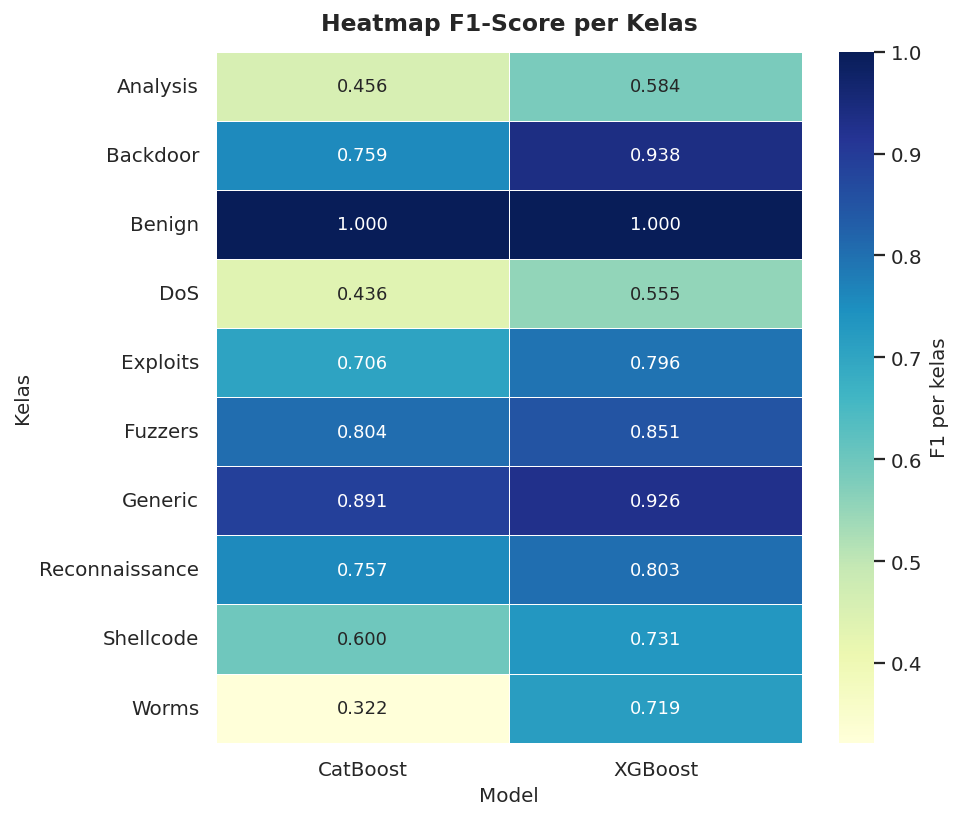

In [11]:
# 8.3 Rekap metrik per kelas dalam format tabel + heatmap
per_class_rows = []

for name in trained_models.keys():
    report_dict = classification_report(
        y_test,
        predictions[name],
        target_names=[str(c) for c in class_names],
        output_dict=True,
        zero_division=0,
    )

    for cls_name in class_names:
        cls_key = str(cls_name)
        cls_metrics = report_dict.get(cls_key, {})
        per_class_rows.append({
            "Model": name,
            "Kelas": cls_key,
            "Precision": cls_metrics.get("precision", np.nan),
            "Recall": cls_metrics.get("recall", np.nan),
            "F1": cls_metrics.get("f1-score", np.nan),
            "Support": cls_metrics.get("support", np.nan),
        })

per_class_df = pd.DataFrame(per_class_rows)
per_class_df = per_class_df.sort_values(by=["Model", "F1"], ascending=[True, False]).reset_index(drop=True)

display(
    per_class_df.style
    .format({
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1": "{:.4f}",
        "Support": "{:.0f}",
    })
    .background_gradient(cmap="YlGn", subset=["Precision", "Recall", "F1"])
    .set_caption("Ringkasan metrik per kelas")
)

per_class_f1_pivot = (
    per_class_df
    .pivot(index="Kelas", columns="Model", values="F1")
    .sort_index()
)

fig_h = max(4.5, 0.48 * len(per_class_f1_pivot) + 1.6)
fig_w = max(7.5, len(per_class_f1_pivot.columns) * 2.2 + 2.5)

fig, ax = plt.subplots(figsize=(fig_w, fig_h))
sns.heatmap(
    per_class_f1_pivot,
    annot=True,
    fmt=".3f",
    cmap="YlGnBu",
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "F1 per kelas"},
    ax=ax,
)

ax.set_title("Heatmap F1-Score per Kelas", pad=12)
ax.set_xlabel("Model")
ax.set_ylabel("Kelas")
ax.set_yticklabels(wrap_labels(per_class_f1_pivot.index, width=22), rotation=0)
plt.tight_layout()
plt.show()

## 9) Visualisasi Hasil (Versi Lebih Rapi untuk Laporan/Jurnal)

Bagian ini menyusun visual dengan gaya yang lebih konsisten dan mudah dibaca pada laporan maupun naskah jurnal.

- **9.1** Perbandingan metrik utama antar model  
- **9.2** Confusion matrix raw dan normalized per model  
- **9.3** Perbandingan efisiensi waktu komputasi  
- **9.4** Heatmap komparasi metrik untuk pembacaan cepat reviewer  

> Seluruh visual diseragamkan dari sisi ukuran, anotasi, label, dan gaya judul agar notebook terasa lebih utuh secara presentasi.

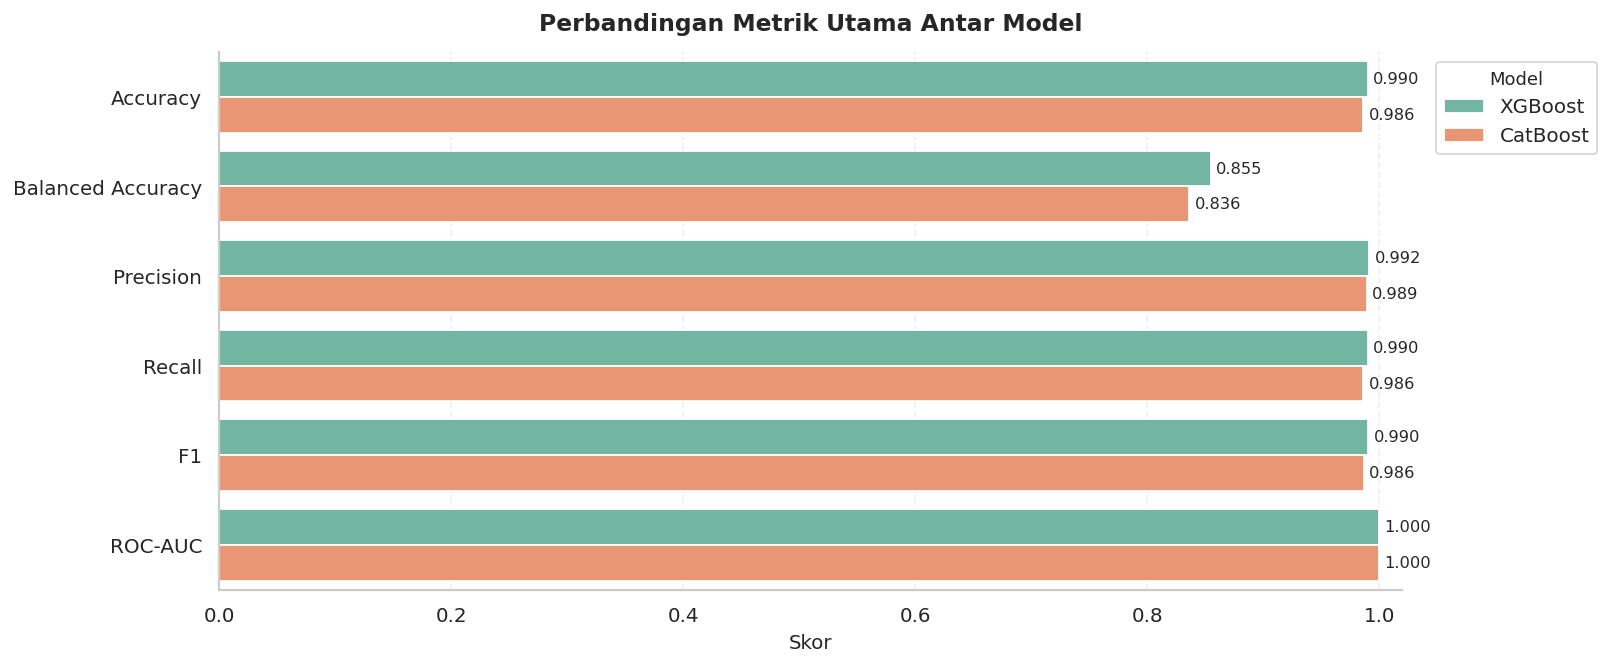

In [12]:
# 9.1 Bar chart metrik utama antar model (layout horizontal agar lebih ringkas)
metrics_to_plot = ["Accuracy", "Balanced Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]

metric_plot_df = results_df.melt(
    id_vars="Model",
    value_vars=metrics_to_plot,
    var_name="Metrik",
    value_name="Skor",
)

metric_plot_df["Metrik"] = pd.Categorical(
    metric_plot_df["Metrik"],
    categories=metrics_to_plot,
    ordered=True,
)

fig_h = max(5.2, 0.62 * len(metrics_to_plot) + 1.5)
fig, ax = plt.subplots(figsize=(12.5, fig_h))

sns.barplot(
    data=metric_plot_df,
    x="Skor",
    y="Metrik",
    hue="Model",
    palette=MODEL_PALETTE,
    ax=ax,
)

ax.set_title("Perbandingan Metrik Utama Antar Model", pad=12)
ax.set_xlabel("Skor")
ax.set_ylabel("")
ax.set_xlim(0, 1.02)
ax.grid(axis="x", linestyle="--", alpha=0.3)
ax.legend(title="Model", bbox_to_anchor=(1.02, 1), loc="upper left")

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", fontsize=9, padding=3)

plt.tight_layout()
plt.show()

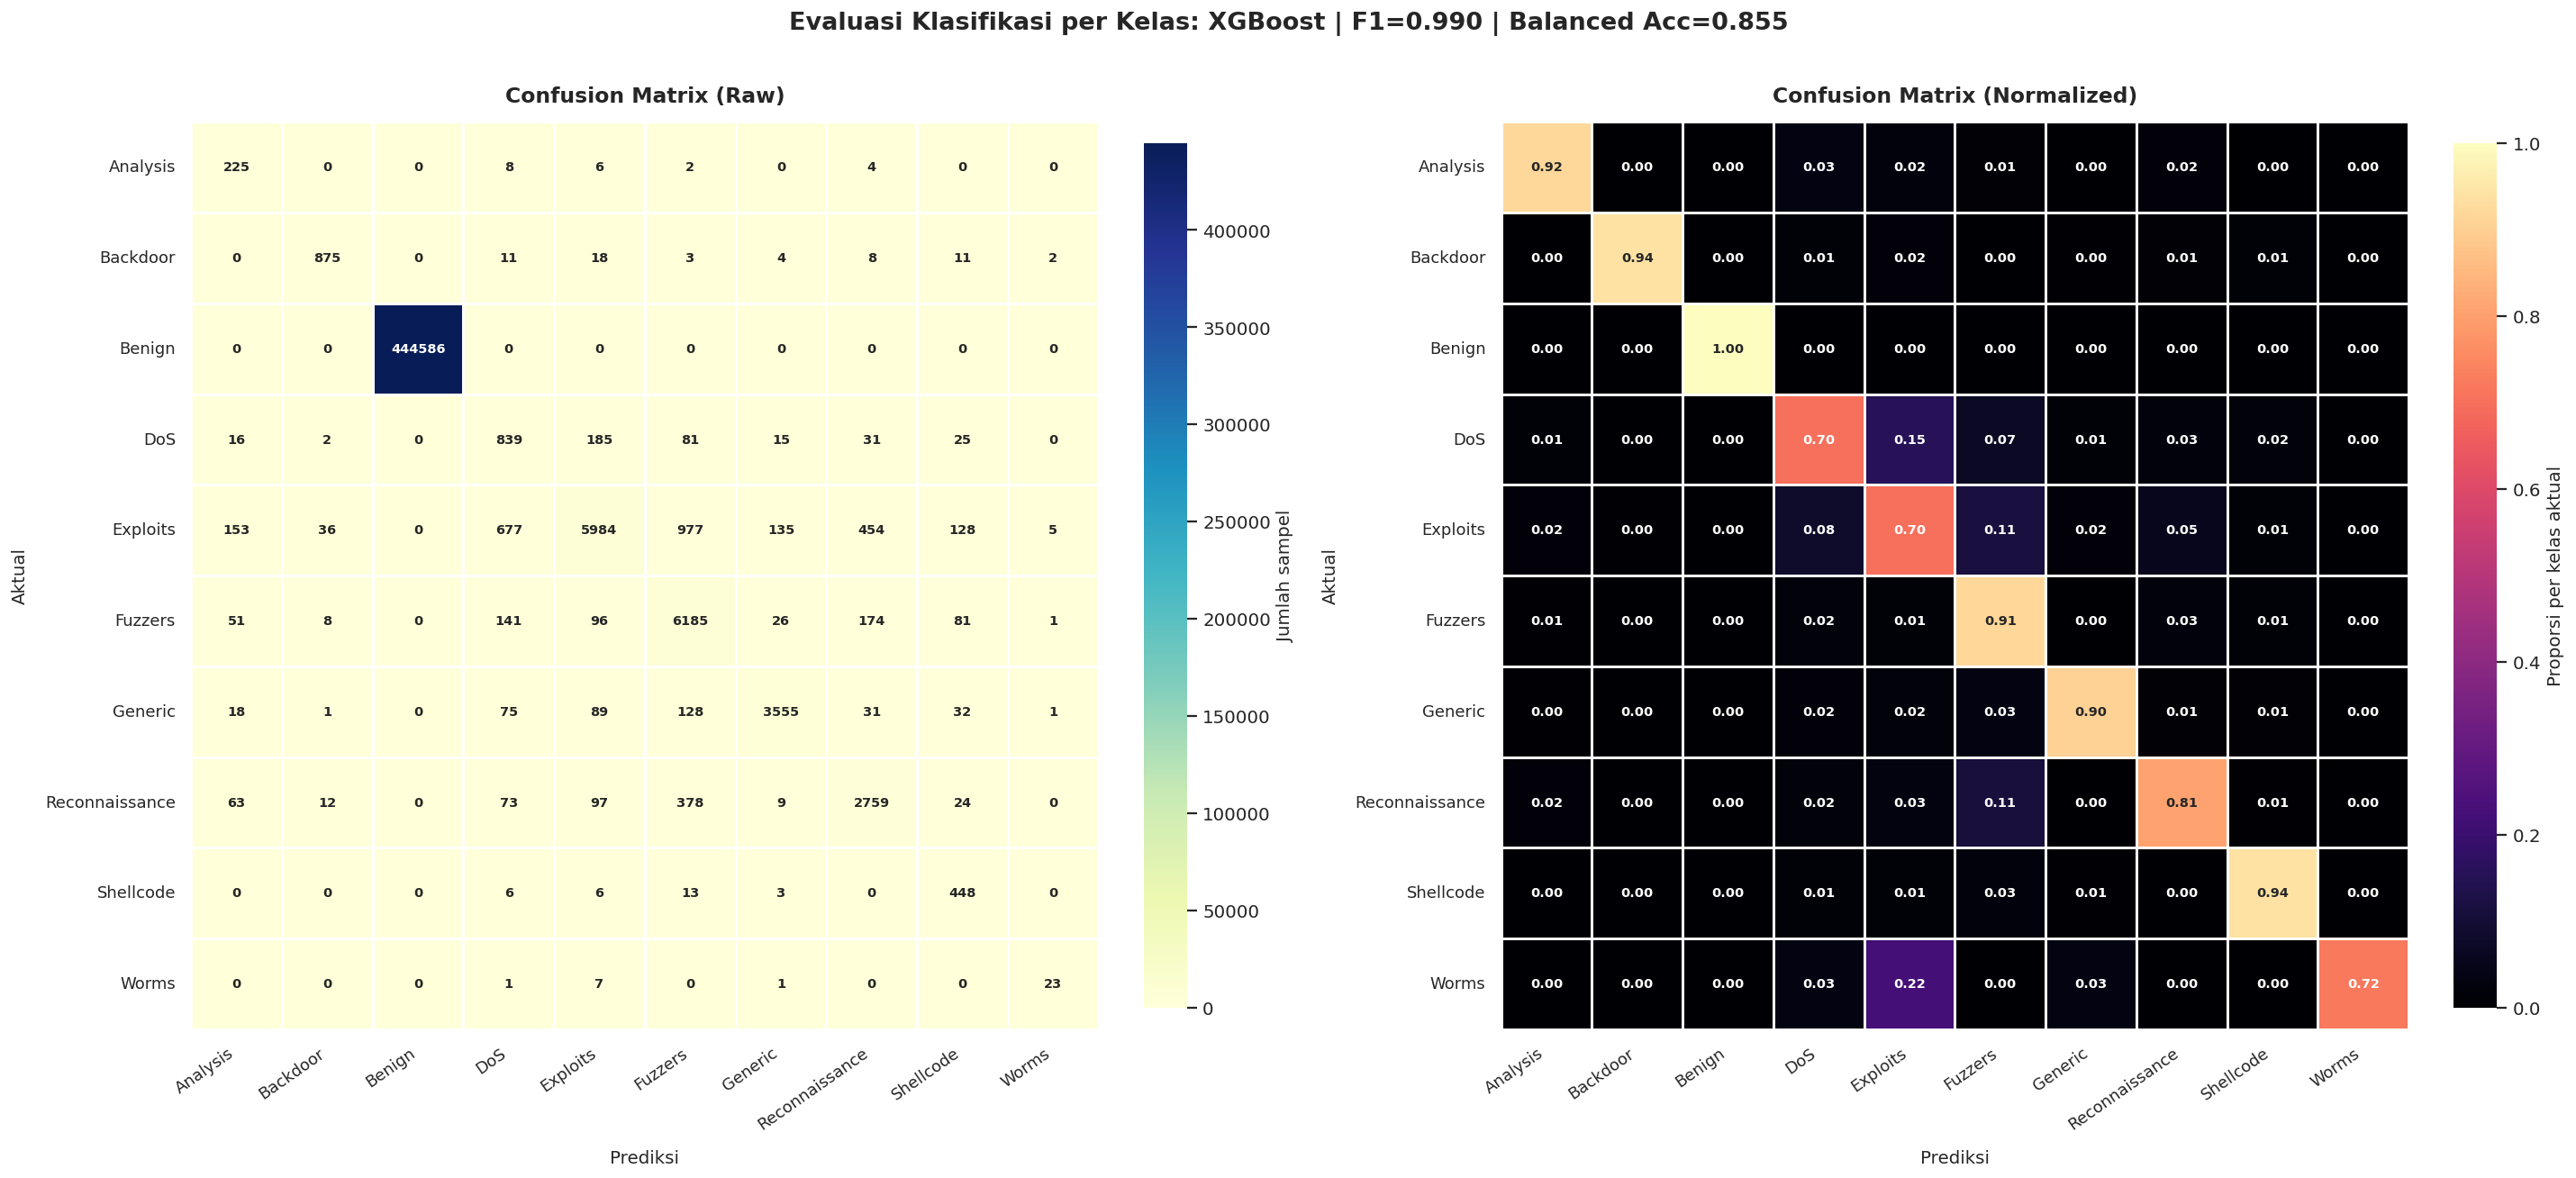

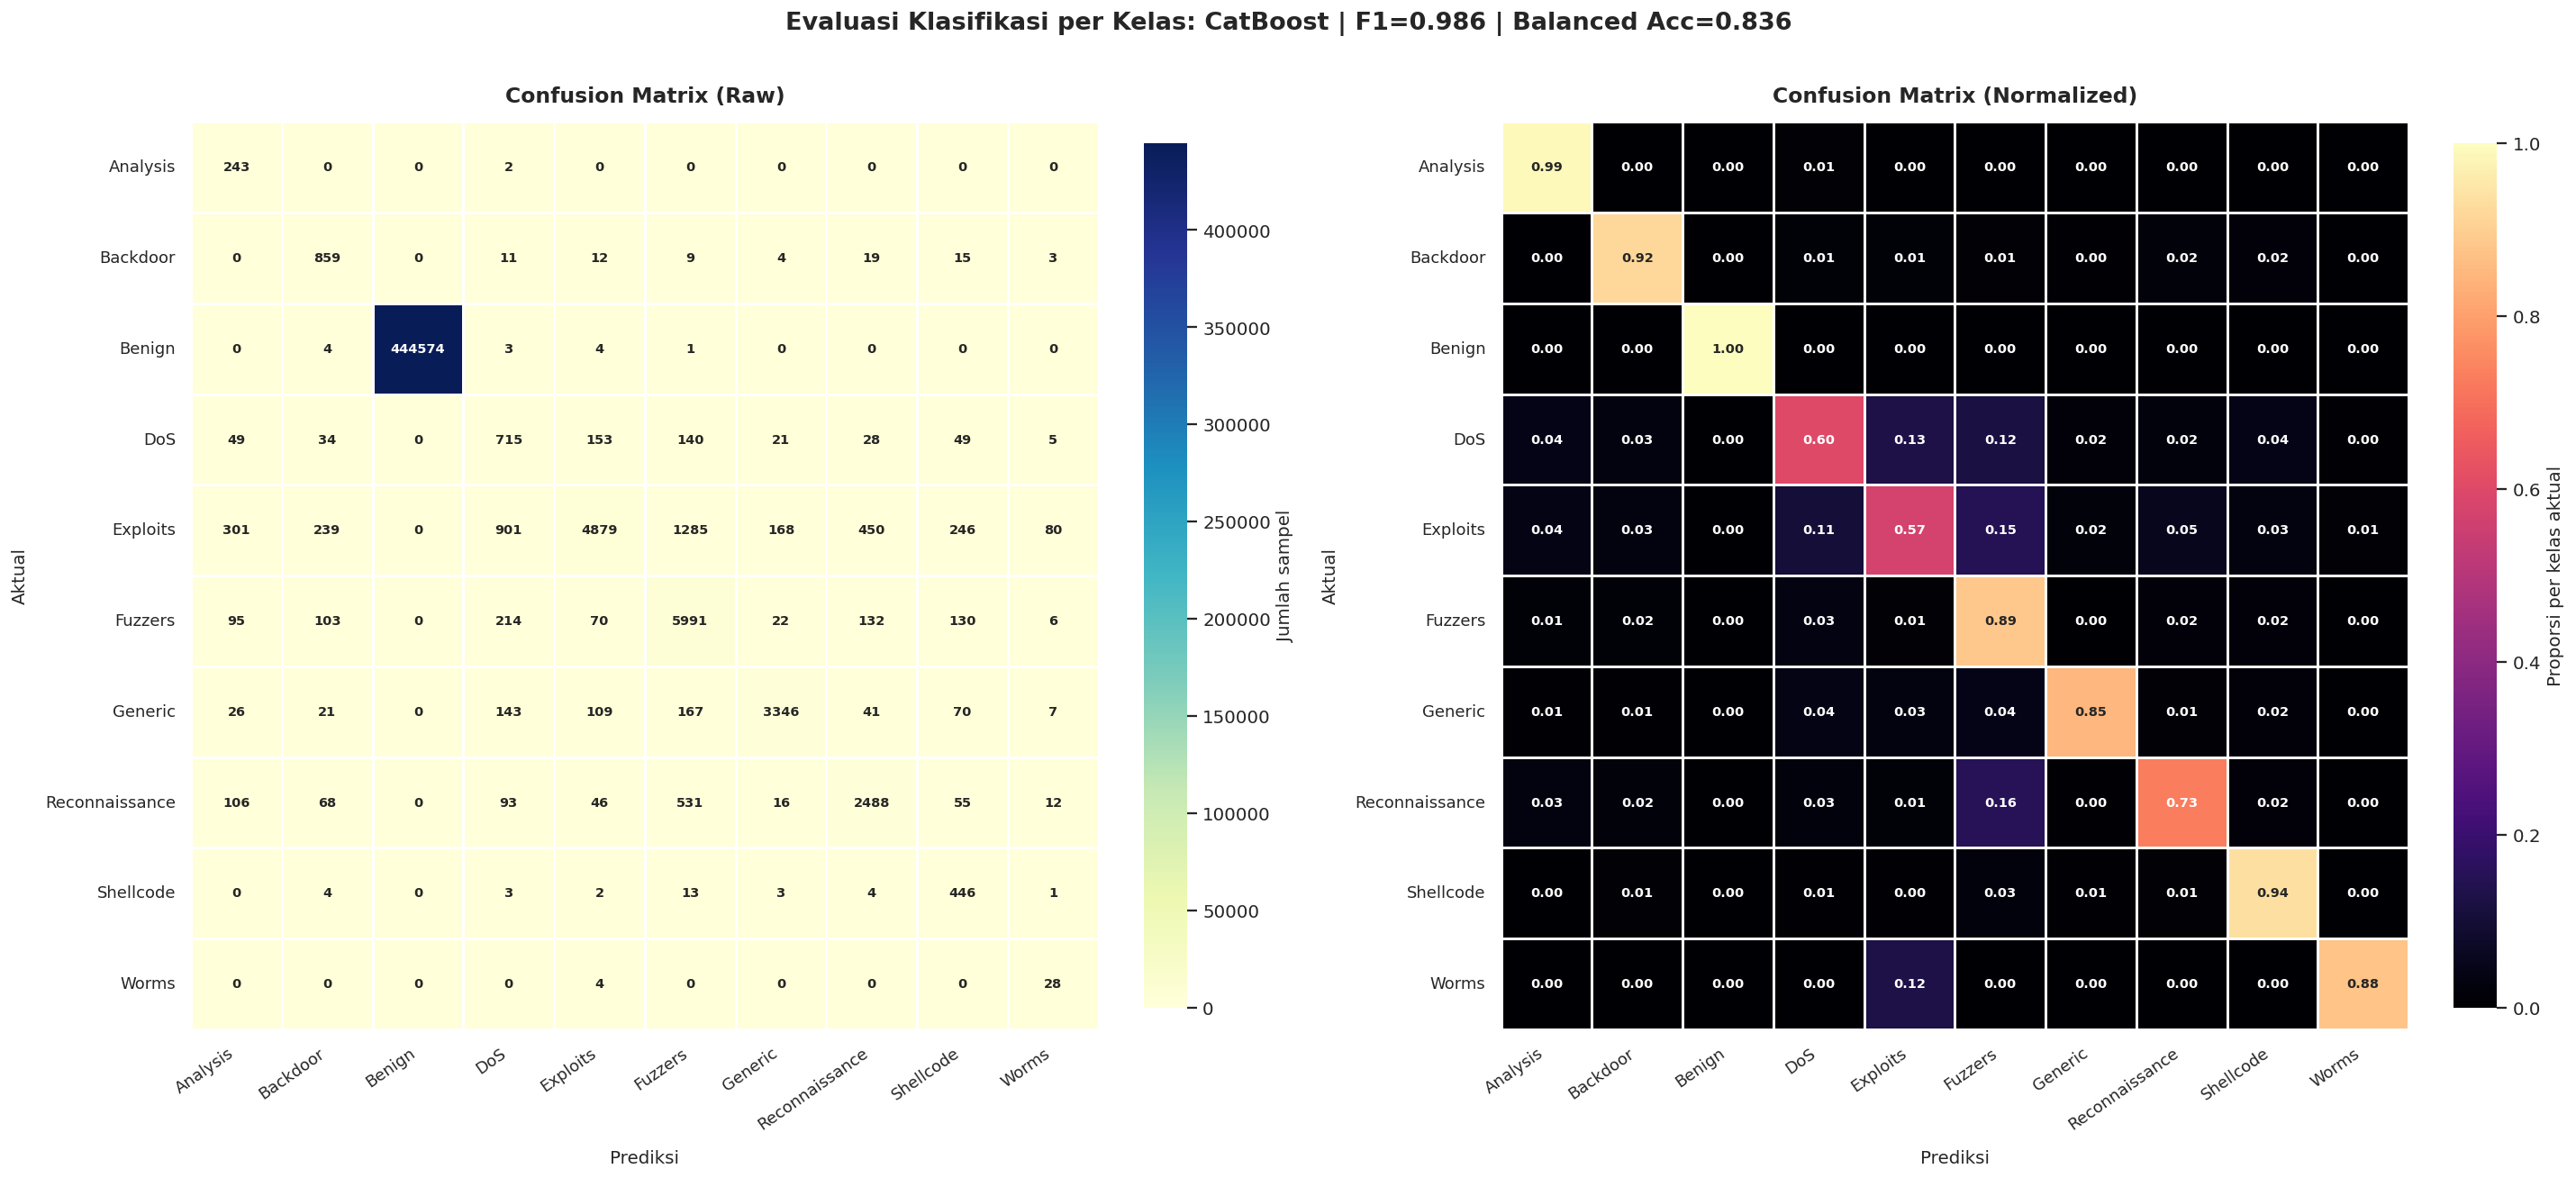

In [13]:
# 9.2 Confusion matrix raw dan normalized per model
model_names = list(trained_models.keys())
class_ids = np.arange(len(class_names))
display_labels = wrap_labels(class_names, width=16)
n_classes = len(display_labels)

max_label_len = max(len(str(c)) for c in class_names)
fig_w = min(max(14, 10 + n_classes * 1.05 + max_label_len * 0.10), 26)
fig_h = min(max(6.5, 4.8 + n_classes * 0.55), 13)
show_annot = n_classes <= 12
annot_size = 11 if n_classes <= 4 else 9 if n_classes <= 8 else 8
x_rotation = 0 if max_label_len <= 10 and n_classes <= 5 else 35
x_ha = "center" if x_rotation == 0 else "right"

score_lookup = results_df.set_index("Model")

for name in model_names:
    cm_raw = confusion_matrix(
        y_test,
        predictions[name],
        labels=class_ids,
    )
    cm_norm = confusion_matrix(
        y_test,
        predictions[name],
        labels=class_ids,
        normalize="true",
    )

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(fig_w, fig_h),
        constrained_layout=True,
    )

    sns.heatmap(
        cm_raw,
        annot=show_annot,
        fmt="d",
        cmap="YlGnBu",
        cbar=True,
        square=True,
        linewidths=0.7,
        linecolor="white",
        ax=axes[0],
        xticklabels=display_labels,
        yticklabels=display_labels,
        annot_kws={"size": annot_size, "weight": "bold"},
        cbar_kws={"shrink": 0.85, "label": "Jumlah sampel"},
    )
    axes[0].set_title("Confusion Matrix (Raw)", fontsize=13, pad=12, fontweight="bold")
    axes[0].set_xlabel("Prediksi", fontsize=11, labelpad=10)
    axes[0].set_ylabel("Aktual", fontsize=11, labelpad=10)

    sns.heatmap(
        cm_norm,
        annot=show_annot,
        fmt=".2f",
        cmap="magma",
        vmin=0,
        vmax=1,
        cbar=True,
        square=True,
        linewidths=0.7,
        linecolor="white",
        ax=axes[1],
        xticklabels=display_labels,
        yticklabels=display_labels,
        annot_kws={"size": annot_size, "weight": "bold"},
        cbar_kws={"shrink": 0.85, "label": "Proporsi per kelas aktual"},
    )
    axes[1].set_title("Confusion Matrix (Normalized)", fontsize=13, pad=12, fontweight="bold")
    axes[1].set_xlabel("Prediksi", fontsize=11, labelpad=10)
    axes[1].set_ylabel("Aktual", fontsize=11, labelpad=10)

    for ax in axes:
        ax.set_xticklabels(ax.get_xticklabels(), rotation=x_rotation, ha=x_ha)
        ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
        ax.tick_params(axis="both", labelsize=10)

    score_row = score_lookup.loc[name]
    fig.suptitle(
        f"Evaluasi Klasifikasi per Kelas: {name} | F1={score_row['F1']:.3f} | Balanced Acc={score_row['Balanced Accuracy']:.3f}",
        fontsize=15,
        fontweight="bold",
    )

    plt.show()
    plt.close(fig)

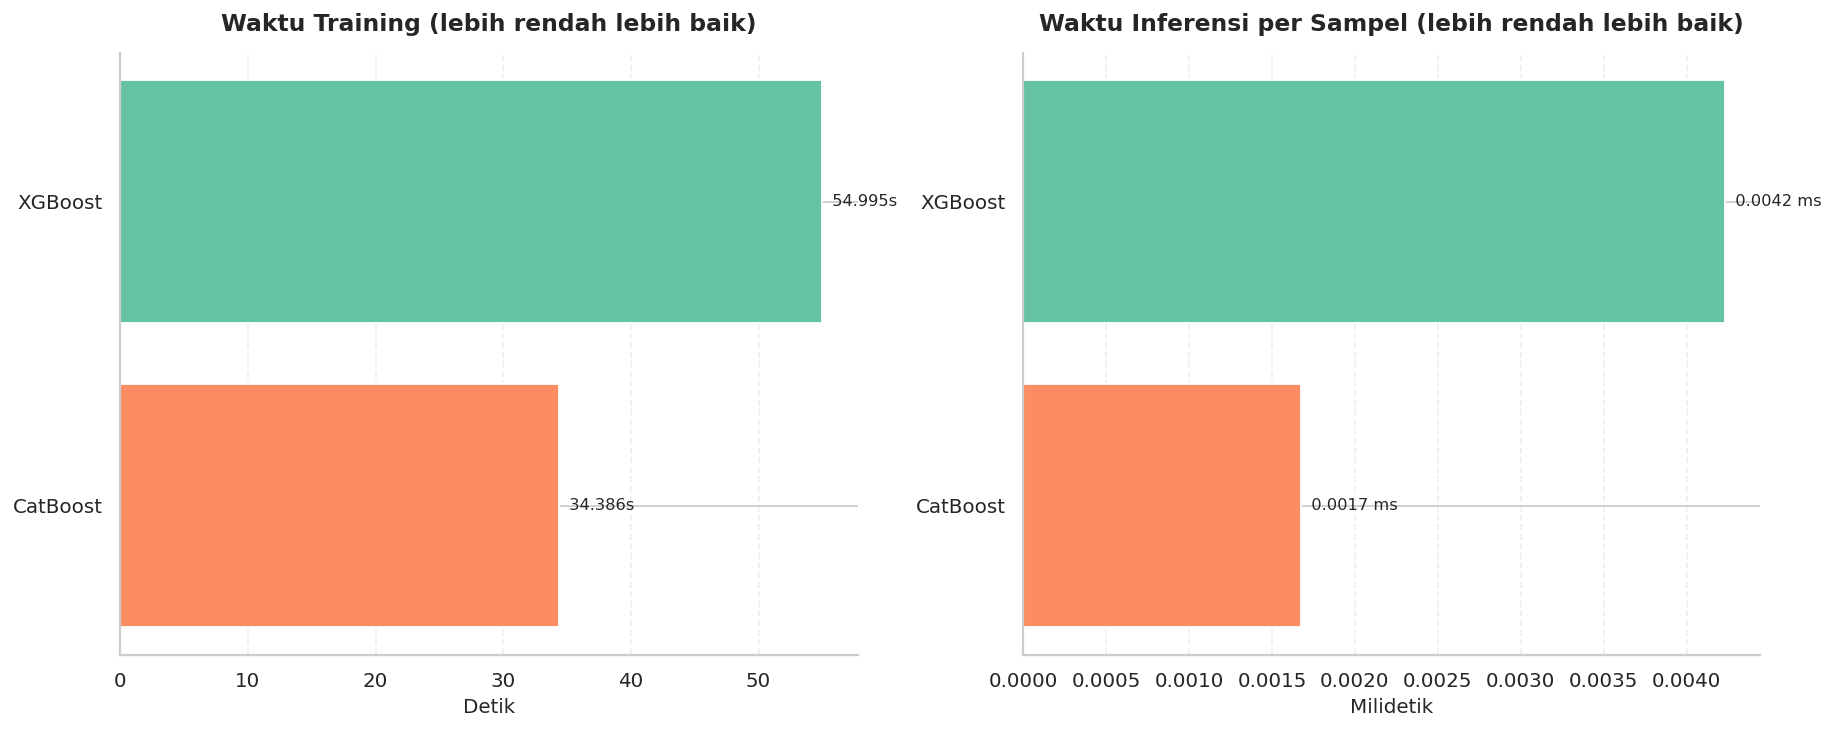

In [14]:
# 9.3 Grafik waktu komputasi (layout horizontal agar perbandingan lebih jelas)
time_plot_df = results_df[["Model", "Train Time (s)", "Inference / Sample (ms)"]].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), constrained_layout=True)

train_df = time_plot_df.sort_values("Train Time (s)", ascending=True)
axes[0].barh(
    train_df["Model"],
    train_df["Train Time (s)"],
    color=[MODEL_PALETTE[m] for m in train_df["Model"]],
)
axes[0].set_title("Waktu Training (lebih rendah lebih baik)", pad=12)
axes[0].set_xlabel("Detik")
axes[0].set_ylabel("")
axes[0].grid(axis="x", linestyle="--", alpha=0.3)

for idx, value in enumerate(train_df["Train Time (s)"]):
    axes[0].text(value, idx, f"  {value:.3f}s", va="center", ha="left", fontsize=9)

infer_df = time_plot_df.sort_values("Inference / Sample (ms)", ascending=True)
axes[1].barh(
    infer_df["Model"],
    infer_df["Inference / Sample (ms)"],
    color=[MODEL_PALETTE[m] for m in infer_df["Model"]],
)
axes[1].set_title("Waktu Inferensi per Sampel (lebih rendah lebih baik)", pad=12)
axes[1].set_xlabel("Milidetik")
axes[1].set_ylabel("")
axes[1].grid(axis="x", linestyle="--", alpha=0.3)

for idx, value in enumerate(infer_df["Inference / Sample (ms)"]):
    axes[1].text(value, idx, f"  {value:.4f} ms", va="center", ha="left", fontsize=9)

plt.show()

### 9.4 Heatmap Komparasi Metrik Antar Model

Visual ini ditranspos agar mudah dibaca saat jumlah model sedikit. Reviewer dapat langsung melihat model mana yang unggul pada setiap metrik tanpa harus memindai tabel numerik satu per satu.

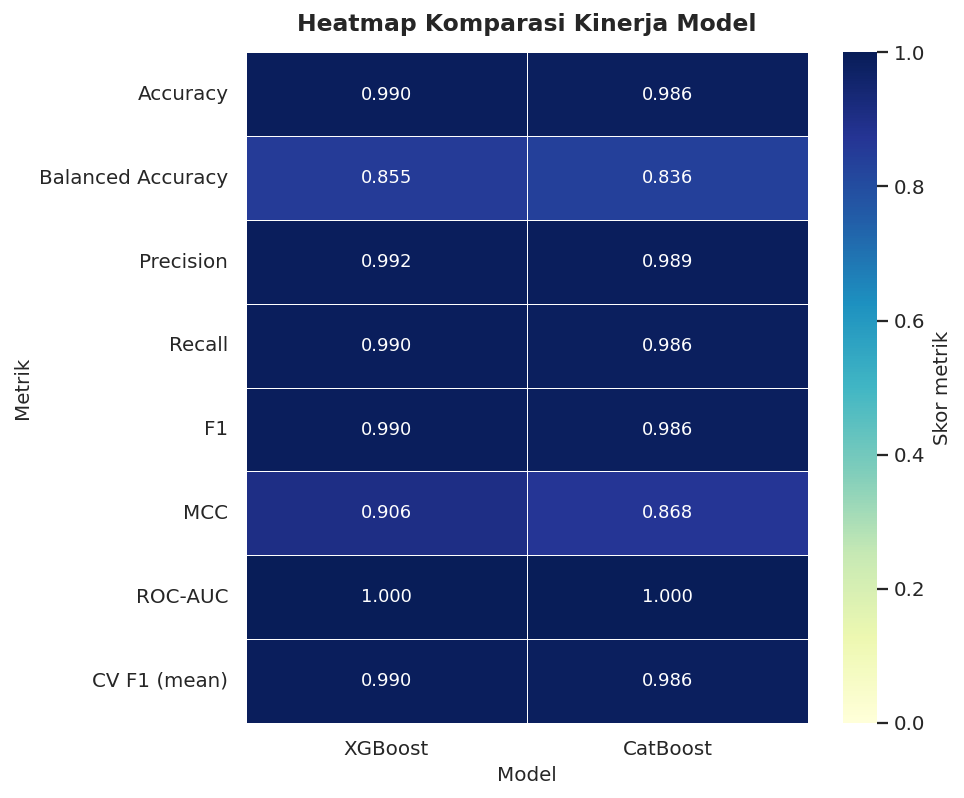

In [15]:
# 9.4 Heatmap komparasi metrik (orientasi ditranspos agar lebih mudah dibaca)
heatmap_metrics = ["Accuracy", "Balanced Accuracy", "Precision", "Recall", "F1", "MCC", "ROC-AUC", "CV F1 (mean)"]
heatmap_df = results_df.set_index("Model")[heatmap_metrics].T

fig_h = max(4.8, 0.58 * len(heatmap_df) + 1.6)
fig_w = max(7.5, len(heatmap_df.columns) * 2.4 + 2.0)

fig, ax = plt.subplots(figsize=(fig_w, fig_h))
sns.heatmap(
    heatmap_df,
    annot=True,
    fmt=".3f",
    cmap="YlGnBu",
    vmin=0,
    vmax=1,
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "Skor metrik"},
    ax=ax,
)

ax.set_title("Heatmap Komparasi Kinerja Model", pad=12)
ax.set_xlabel("Model")
ax.set_ylabel("Metrik")
ax.set_yticklabels(wrap_labels(heatmap_df.index, width=18), rotation=0)
plt.tight_layout()
plt.show()

## 10) Analisis Hasil Komparatif

Bagian ini merangkum:
- model yang paling akurat,
- model yang paling stabil antar-kelas,
- model yang paling efisien secara komputasi,
- serta trade-off performa vs efisiensi untuk konteks IDS real-time.

Tujuannya adalah menghasilkan interpretasi yang lebih naratif, bukan sekadar daftar angka.

In [16]:
# 10.1 Ringkasan analisis otomatis
best_accuracy_model = results_df.sort_values("Accuracy", ascending=False).iloc[0]["Model"]
best_balanced_model = results_df.sort_values("Balanced Accuracy", ascending=False).iloc[0]["Model"]
best_mcc_model = results_df.sort_values("MCC", ascending=False).iloc[0]["Model"]
fastest_train_model = results_df.sort_values("Train Time (s)", ascending=True).iloc[0]["Model"]
fastest_infer_model = results_df.sort_values("Inference / Sample (ms)", ascending=True).iloc[0]["Model"]

metric_winners_df = pd.DataFrame(
    [
        {"Aspek": "Accuracy tertinggi", "Model": best_accuracy_model},
        {"Aspek": "Balanced Accuracy tertinggi", "Model": best_balanced_model},
        {"Aspek": "MCC tertinggi", "Model": best_mcc_model},
        {"Aspek": "Training tercepat", "Model": fastest_train_model},
        {"Aspek": "Inferensi tercepat", "Model": fastest_infer_model},
        {"Aspek": "Peringkat akhir (F1 → Recall)", "Model": best_model_name},
    ]
)

display(style_metric_table(metric_winners_df, caption="Pemenang per aspek evaluasi"))

tradeoff_cols = [
    "Rank (F1->Recall)",
    "Model",
    "Accuracy",
    "Balanced Accuracy",
    "F1",
    "MCC",
    "CV F1 (mean)",
    "CV F1 (std)",
    "Train Time (s)",
    "Inference / Sample (ms)",
]

display(
    style_metric_table(
        results_df[tradeoff_cols].copy(),
        metric_cols=["Accuracy", "Balanced Accuracy", "F1", "MCC", "CV F1 (mean)"],
        time_cols=["Train Time (s)", "Inference / Sample (ms)"],
        caption="Ringkasan trade-off performa vs efisiensi"
    ).format({
        "Rank (F1->Recall)": "{:.0f}",
        "Accuracy": "{:.4f}",
        "Balanced Accuracy": "{:.4f}",
        "F1": "{:.4f}",
        "MCC": "{:.4f}",
        "CV F1 (mean)": "{:.4f}",
        "CV F1 (std)": "{:.4f}",
        "Train Time (s)": "{:.3f}",
        "Inference / Sample (ms)": "{:.4f}",
    })
)

print("📌 Ringkasan Analisis Komparatif")
print(f"- Model paling akurat                : {best_accuracy_model}")
print(f"- Model paling stabil antar-kelas    : {best_balanced_model}")
print(f"- Model korelasi prediksi tertinggi  : {best_mcc_model}")
print(f"- Model training tercepat            : {fastest_train_model}")
print(f"- Model inferensi tercepat           : {fastest_infer_model}")
print(f"- Model terbaik (prioritas F1/Recall): {best_model_name}")

print()
print("Trade-off performa vs efisiensi:")
for _, row in results_df.iterrows():
    print(
        f"  • {row['Model']}: F1={row['F1']:.4f}, Recall={row['Recall']:.4f}, "
        f"Bal.Acc={row['Balanced Accuracy']:.4f}, MCC={row['MCC']:.4f}, "
        f"CV F1={row['CV F1 (mean)']:.4f}±{row['CV F1 (std)']:.4f}, "
        f"Train={row['Train Time (s)']:.3f}s, Infer/sample={row['Inference / Sample (ms)']:.4f}ms"
    )

,Aspek,Model
0,Accuracy tertinggi,XGBoost
1,Balanced Accuracy tertinggi,XGBoost
2,MCC tertinggi,XGBoost
3,Training tercepat,CatBoost
4,Inferensi tercepat,CatBoost
5,Peringkat akhir (F1 → Recall),XGBoost


,Rank (F1->Recall),Model,Accuracy,Balanced Accuracy,F1,MCC,CV F1 (mean),CV F1 (std),Train Time (s),Inference / Sample (ms)
0,1,XGBoost,0.9901,0.8547,0.9903,0.9061,0.9901,0.0001,54.995,0.0042
1,2,CatBoost,0.9861,0.8361,0.9865,0.8677,0.9863,0.0001,34.386,0.0017


📌 Ringkasan Analisis Komparatif
- Model paling akurat                : XGBoost
- Model paling stabil antar-kelas    : XGBoost
- Model korelasi prediksi tertinggi  : XGBoost
- Model training tercepat            : CatBoost
- Model inferensi tercepat           : CatBoost
- Model terbaik (prioritas F1/Recall): XGBoost

Trade-off performa vs efisiensi:
  • XGBoost: F1=0.9903, Recall=0.9901, Bal.Acc=0.8547, MCC=0.9061, CV F1=0.9901±0.0001, Train=54.995s, Infer/sample=0.0042ms
  • CatBoost: F1=0.9865, Recall=0.9861, Bal.Acc=0.8361, MCC=0.8677, CV F1=0.9863±0.0001, Train=34.386s, Infer/sample=0.0017ms


## 11) Checklist Komponen Penting untuk Penulisan Jurnal

Bagian ini membantu memastikan elemen inti naskah jurnal telah tersedia dari notebook, mulai dari deskripsi dataset hingga interpretasi hasil. Gunakan checklist berikut sebagai panduan sebelum memindahkan hasil ke manuskrip akhir.

In [17]:
# 11.1 Checklist otomatis komponen penting naskah jurnal
winner = results_df.iloc[0]

checklist_df = pd.DataFrame(
    [
        {"No": 1, "Komponen": "Deskripsi dataset", "Detail minimum": "Ukuran data, jumlah fitur, jumlah kelas, dan distribusi label"},
        {"No": 2, "Komponen": "Protokol eksperimen", "Detail minimum": "Split train/test, preprocessing, dan penanganan imbalance"},
        {"No": 3, "Komponen": "Spesifikasi baseline model", "Detail minimum": "Parameter inti XGBoost & CatBoost serta mode CPU/GPU"},
        {"No": 4, "Komponen": "Hasil kuantitatif utama", "Detail minimum": "Accuracy, Balanced Accuracy, Precision, Recall, F1, MCC, ROC-AUC"},
        {"No": 5, "Komponen": "Validasi statistik", "Detail minimum": "CV weighted F1 (mean±std)"},
        {"No": 6, "Komponen": "Visualisasi wajib", "Detail minimum": "Distribusi label, bar metrik, confusion matrix, waktu komputasi, heatmap"},
        {"No": 7, "Komponen": "Analisis trade-off", "Detail minimum": "Model terbaik vs model tercepat untuk skenario real-time"},
        {"No": 8, "Komponen": "Keterbatasan studi", "Detail minimum": "Tuning belum ekstensif, sensitivitas terhadap kualitas data, dan arah pengembangan"},
    ]
)

display(style_metric_table(checklist_df, caption="Checklist konten yang disarankan untuk naskah jurnal"))

print("Ringkasan model pemenang saat ini:")
print(
    f"- {winner['Model']} | F1={winner['F1']:.4f}, Recall={winner['Recall']:.4f}, "
    f"Balanced Accuracy={winner['Balanced Accuracy']:.4f}, MCC={winner['MCC']:.4f}"
)

,No,Komponen,Detail minimum
0,1,Deskripsi dataset,"Ukuran data, jumlah fitur, jumlah kelas, dan distribusi label"
1,2,Protokol eksperimen,"Split train/test, preprocessing, dan penanganan imbalance"
2,3,Spesifikasi baseline model,Parameter inti XGBoost & CatBoost serta mode CPU/GPU
3,4,Hasil kuantitatif utama,"Accuracy, Balanced Accuracy, Precision, Recall, F1, MCC, ROC-AUC"
4,5,Validasi statistik,CV weighted F1 (mean±std)
5,6,Visualisasi wajib,"Distribusi label, bar metrik, confusion matrix, waktu komputasi, heatmap"
6,7,Analisis trade-off,Model terbaik vs model tercepat untuk skenario real-time
7,8,Keterbatasan studi,"Tuning belum ekstensif, sensitivitas terhadap kualitas data, dan arah pengembangan"


Ringkasan model pemenang saat ini:
- XGBoost | F1=0.9903, Recall=0.9901, Balanced Accuracy=0.8547, MCC=0.9061


## 12) Kesimpulan Komparasi

Gunakan sel berikut untuk menghasilkan kesimpulan otomatis berbasis metrik. Narasi ini dapat langsung dijadikan draft awal pada bagian **hasil dan pembahasan** atau **kesimpulan** dalam artikel, lalu disesuaikan dengan konteks penelitian.

In [18]:
# 12.1 Kesimpulan otomatis
winner = results_df.iloc[0]

print("=" * 90)
print("KESIMPULAN KOMPARASI")
print("=" * 90)
print(
    f"Model terbaik pada eksperimen ini adalah {winner['Model']} "
    f"(berdasarkan prioritas F1/Recall)."
)
print(
    f"Nilai utama: Accuracy={winner['Accuracy']:.4f}, Balanced Accuracy={winner['Balanced Accuracy']:.4f}, "
    f"Precision={winner['Precision']:.4f}, Recall={winner['Recall']:.4f}, F1={winner['F1']:.4f}, "
    f"MCC={winner['MCC']:.4f}, ROC-AUC={winner['ROC-AUC']:.4f}."
)
print()
print("Justifikasi:")
print("- Pemilihan model didasarkan pada ranking F1 lalu Recall untuk konteks IDS.")
print("- Balanced Accuracy dan MCC ditambahkan untuk menilai kestabilan prediksi pada data tidak seimbang.")
print("- Waktu training dan inferensi turut dipertimbangkan untuk kebutuhan implementasi real-time.")
print()
print("Catatan keterbatasan komparasi:")
print("- Baseline hyperparameter belum dilakukan tuning ekstensif.")
print("- Variansi antarfold perlu dipertimbangkan bersama metrik hold-out test.")
print("- Hasil sensitif terhadap kualitas data dan distribusi kelas pada NF-UNSW-NB15-v3.")

KESIMPULAN KOMPARASI
Model terbaik pada eksperimen ini adalah XGBoost (berdasarkan prioritas F1/Recall).
Nilai utama: Accuracy=0.9901, Balanced Accuracy=0.8547, Precision=0.9915, Recall=0.9901, F1=0.9903, MCC=0.9061, ROC-AUC=0.9999.

Justifikasi:
- Pemilihan model didasarkan pada ranking F1 lalu Recall untuk konteks IDS.
- Balanced Accuracy dan MCC ditambahkan untuk menilai kestabilan prediksi pada data tidak seimbang.
- Waktu training dan inferensi turut dipertimbangkan untuk kebutuhan implementasi real-time.

Catatan keterbatasan komparasi:
- Baseline hyperparameter belum dilakukan tuning ekstensif.
- Variansi antarfold perlu dipertimbangkan bersama metrik hold-out test.
- Hasil sensitif terhadap kualitas data dan distribusi kelas pada NF-UNSW-NB15-v3.
